# Class 3: Word Embeddings & Sentiment Analysis
## Learning Notebook Part 2 - Sentence Embeddings & Classification

**Welcome!** This notebook focuses on **sentence-level embeddings** (BERT, Sentence-BERT) and using them for **classification**.

**What you've learned so far:**
- ✅ Part 1: Introduced Word2Vec, GloVe, FastText - word-level embeddings
- ✅ You've seen how embeddings solve the synonym problem
- ✅ You understand semantic vs syntactic representations
- ✅ You've explored word embeddings, visualized them, and tested semantic search
- ✅ You've seen how to create sentence embeddings by averaging word embeddings

**Today you'll learn:**
- 🎯 **How sentence/document embeddings are learned**: Three training objectives (conceptually explained!)
  - Predicting what's next (Next-token prediction - GPT style)
  - Predicting what's missing (Masked Language Modeling - BERT style)
  - Predicting what's similar (Contrastive learning - Sentence-BERT style)
- 🎯 **Key concept**: LEARN = Adjust the vectors (adjusting representations based on objectives)
- 🎯 **Sentence-level embeddings**: BERT and Sentence-BERT (better than word averaging!)
- 🎯 **Using sentence embeddings for classification**: Compare Sentence-BERT vs word averaging

**Main Purpose**: 
- **Understand how sentence/document embeddings are learned** - three training objectives (conceptually explained!)
  - Next-token prediction (GPT) - predicting what's next
  - Masked Language Modeling (BERT) - predicting what's missing
  - Contrastive learning (Sentence-BERT) - predicting what's similar
- **Key concept**: LEARN = Adjust the vectors (adjusting representations based on training objectives)
- **Focus on sentence-level embeddings** - BERT, Sentence-BERT, and how they're trained
- **Use sentence embeddings for classification** - see how they outperform word averaging
- This previews supervised learning - you'll learn classification, feature engineering, and evaluation in depth later
- The goal: Understand how embeddings learn (by adjusting vectors) and see how sentence embeddings capture sentence-level meaning better than averaging word embeddings!

**By the end**: You'll understand how sentence/document embeddings are learned (all three training objectives conceptually), the key concept that learning = adjusting vectors, and how Sentence-BERT improves classification compared to word averaging!

**Key Insight**: Sentence embeddings learn by adjusting vector representations based on training objectives. All three methods (next-token prediction, masked language modeling, contrastive learning) require understanding context first, then adjust vectors to improve predictions. Sentence-BERT (trained with contrastive learning) captures sentence-level meaning, word order, and context better than averaging word embeddings!


---

## Setup


In [13]:
# Install required packages if not already installed
# Uncomment the lines below if packages are not installed
# !pip install gensim
# !pip install spacy
# !pip install sentence-transformers
# python -m spacy download en_core_web_sm  # Run this after installing spacy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import re
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
try:
    import spacy
    nlp = spacy.load('en_core_web_sm')
    SPACY_AVAILABLE = True
except:
    print("⚠️ spaCy not available. Install with: pip install spacy && python -m spacy download en_core_web_sm")
    SPACY_AVAILABLE = False
    nlp = None

try:
    from sentence_transformers import SentenceTransformer
    SENTENCE_TRANSFORMERS_AVAILABLE = True
except:
    print("⚠️ sentence-transformers not available. Install with: pip install sentence-transformers")
    SENTENCE_TRANSFORMERS_AVAILABLE = False

# Set style for better plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully!")


✓ Libraries imported successfully!


---

## Section 1: Quick Baseline - Word Averaging for Classification

**From Part 1: Word Embeddings → Sentence Embeddings**

In Part 1, you learned to create sentence embeddings by **averaging word embeddings** (Word2Vec, GloVe, FastText). Let's quickly use this approach for classification as a baseline!

**What we'll do**: 
- Quick baseline: Use word averaging (from Part 1) for sentiment classification
- Then we'll see how **sentence-level embeddings** (BERT, Sentence-BERT) improve on this!

**Key Point**: Word averaging works, but sentence embeddings are better! That's what we'll explore next.

---

## Section 2: How Sentence/Document Embeddings Are Learned

**The Problem with Word Averaging:**

In Part 1, you created sentence embeddings by averaging word embeddings:
```python
sentence = "I love this movie"
sentence_embedding = mean([word2vec["I"], word2vec["love"], word2vec["this"], word2vec["movie"]])
```

**Limitations:**
- ❌ Loses word order: "I love Python" vs "Python I love" → same embedding!
- ❌ Equal weights: "I" and "love" contribute equally (but "love" is more important!)
- ❌ No sentence-level understanding: Doesn't capture sentence meaning as a whole

**The Solution: Learning Sentence/Document Embeddings**

**Key Concept: LEARN = Adjust the Vectors**

When we say embeddings "learn", we mean:
- **Adjusting the vector representations** (the numbers in the embedding)
- **Based on a training objective** (what we want the model to predict)
- **To better capture meaning** (semantic understanding)

**Three Main Ways to Learn Sentence/Document Embeddings:**

### 1. Predicting What's Next (Next-Token Prediction - GPT Style)

**What it does**: Predict the next word in a sequence

**Example:**
```
Input: "The cat sat on"
Model must predict: "the" (next word)

Input: "The cat sat on the"
Model must predict: "mat" (next word)
```

**How it learns:**
- Model reads left-to-right (like reading a book)
- To predict correctly, it must **understand the context** of what came before
- **Learning = Adjusting vectors** so the model can predict what comes next
- The better it understands context, the better it predicts → better embeddings!

**What it powers**: GPT models (GPT-2, GPT-3, GPT-4, ChatGPT)

**Key Insight**: 
- Must first **learn context** to predict what's next
- By learning to predict, it learns to represent sentences/documents meaningfully
- **LEARN = Adjust vectors** to improve next-word prediction

### 2. Predicting What's Missing (Masked Language Modeling - BERT Style)

**What it does**: Predict masked words in context

**Example:**
```
Input: "The cat [MASK] on the mat"
Model must predict: "sat" (what's missing)

Input: "The [MASK] sat on the mat"
Model must predict: "cat" (what's missing)
```

**How it learns:**
- Model sees **BOTH left AND right context** (unlike GPT!)
- To predict correctly, it must **understand the full context** around the mask
- **Learning = Adjusting vectors** so the model can predict masked words
- The better it understands bidirectional context, the better it predicts → better embeddings!

**What it powers**: BERT models (BERT, RoBERTa, DistilBERT)

**Key Insight**:
- Must first **learn bidirectional context** to predict what's missing
- By learning to predict masked words, it learns to represent sentences/documents meaningfully
- **LEARN = Adjust vectors** to improve masked-word prediction
- Better context understanding than GPT (sees both sides!)

### 3. Predicting What's Similar (Contrastive Learning - Sentence-BERT Style)

**What it does**: Similar sentences close together, dissimilar sentences far apart

**Example:**
```
Similar sentences (should be close):
"I love this movie" ●
"This film is great" ●  ← Close together (similar meaning!)

Dissimilar sentences (should be far):
"I love this movie" ●
"I hate this movie" ●  ← Far apart (opposite meaning!)
```

**How it learns:**
- Model trains on sentence pairs (similar/dissimilar)
- Similar pairs → **adjust vectors** to move closer together
- Dissimilar pairs → **adjust vectors** to move farther apart
- **Learning = Adjusting vectors** so similar sentences are close, dissimilar are far
- The better it distinguishes similarity, the better the embeddings!

**What it powers**: Sentence-BERT, Universal Sentence Encoder

**Key Insight**:
- Must first **learn what makes sentences similar/dissimilar**
- By learning similarity, it learns to represent sentences meaningfully
- **LEARN = Adjust vectors** to push similar together, dissimilar apart
- Trained specifically for sentence similarity (best for sentence embeddings!)

**The Common Thread:**

All three methods:
1. **Require understanding context first** - to predict next word, masked word, or similarity
2. **Learn by adjusting vectors** - the embedding numbers change based on the objective
3. **Result in better representations** - embeddings that capture meaning better than averaging

**Why Sentence-BERT is Better Than Word Averaging:**

**Sentence-BERT** combines:
- **BERT's understanding** (from MLM - bidirectional context)
- **Contrastive learning** (trained specifically for sentence similarity)

This gives us:
- ✅ Captures sentence-level meaning (not just word average)
- ✅ Handles word order ("I love Python" ≠ "Python I love")
- ✅ Trained specifically for sentences (contrastive learning)
- ✅ Better for similarity tasks and classification!

**Reference**: 
- Sentence-BERT: Reimers & Gurevych, 2019 - "Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks"
- BERT: Devlin et al., 2018 - "BERT: Pre-training of Deep Bidirectional Transformers"
- GPT: Radford et al., 2019 - "Language Models are Unsupervised Multitask Learners"
- See Class 3 theory slides for more details on all three training objectives!




In [14]:
# Load dataset (must be done before baseline)
import os

if os.path.exists('data/IMDB Dataset.csv'):
    df = pd.read_csv('data/IMDB Dataset.csv')
elif os.path.exists('../data/IMDB Dataset.csv'):
    df = pd.read_csv('../data/IMDB Dataset.csv')
else:
    # Create sample dataset
    sample_reviews = [
        ("This movie was absolutely amazing! I loved every minute.", "positive"),
        ("Terrible film. Waste of time and money.", "negative"),
        ("The acting was superb and the plot kept me engaged.", "positive"),
        ("Boring and predictable. Would not recommend.", "negative"),
        ("One of the best movies I've seen this year!", "positive"),
        ("Disappointed. The trailer was better than the movie.", "negative"),
        ("Great storyline with unexpected twists.", "positive"),
        ("Poor acting and weak script.", "negative"),
        ("Absolutely brilliant! A masterpiece.", "positive"),
        ("Not worth watching. Very dull.", "negative"),
    ] * 5000
    
    df = pd.DataFrame(sample_reviews, columns=['review', 'sentiment'])

print(f"Loaded {len(df)} reviews")
print("\n💡 We'll use this dataset to compare word averaging vs sentence embeddings for classification!")

# Prepare data
SAMPLE_SIZE = 10000  # Use same size as Part 1 for consistency
df_sample = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42).reset_index(drop=True)
X = df_sample['review'].values
y = df_sample['sentiment'].map({'positive': 1, 'negative': 0}).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print("\n💡 Now let's create the baseline using word averaging!")

Loaded 50000 reviews

💡 We'll use this dataset to compare word averaging vs sentence embeddings for classification!
Train: 8000, Test: 2000

💡 Now let's create the baseline using word averaging!


**Quick Baseline: Word Averaging for Classification**

This creates a baseline using word averaging (from Part 1) to compare with Sentence-BERT later.

**What we'll do:**
- Use Word2Vec with word averaging (from Part 1) to create sentence embeddings
- Train a classifier on these embeddings
- Store the accuracy as our baseline (`accuracy_word_avg`)
- Later, we'll compare Sentence-BERT against this baseline to see the improvement!


In [15]:
# Create word averaging baseline
print("="*70)
print("Section 1: Word Averaging Baseline")
print("="*70)
print("\nCreating baseline using word averaging (from Part 1)...")
print("We'll use Word2Vec as the baseline method.\n")

accuracy_word_avg = None

try:
    import gensim.downloader as api
    
    # Function to create document embeddings by averaging word vectors
    def average_word_vectors(text, model, dim=300):
        """Create document embedding by averaging word vectors"""
        words = text.lower().split()
        vectors = []
        for word in words:
            word = word.strip('.,!?;:()[]{}"\'').lower()
            if word in model:
                vectors.append(model[word])
        if len(vectors) == 0:
            return np.zeros(dim)
        return np.mean(vectors, axis=0)
    
    # Load Word2Vec model
    print("Loading Word2Vec model (300 dimensions)...")
    word2vec_model = api.load('word2vec-google-news-300')
    print("✓ Word2Vec loaded!")
    
    # Create embeddings using word averaging
    print("Creating document embeddings (word averaging)...")
    X_train_avg = np.array([average_word_vectors(text, word2vec_model, 300) for text in X_train])
    X_test_avg = np.array([average_word_vectors(text, word2vec_model, 300) for text in X_test])
    
    # Train classifier
    print("Training classifier...")
    classifier_avg = LogisticRegression(max_iter=1000, random_state=42)
    classifier_avg.fit(X_train_avg, y_train)
    
    # Evaluate
    y_pred_avg = classifier_avg.predict(X_test_avg)
    accuracy_word_avg = accuracy_score(y_test, y_pred_avg)
    
    print(f"\n✓ Word Averaging Baseline Results:")
    print(f"  Accuracy: {accuracy_word_avg:.4f} ({accuracy_word_avg*100:.2f}%)")
    print(f"\n💡 This is our baseline - we'll compare Sentence-BERT against this!")
    
except Exception as e:
    print(f"⚠️ Could not create baseline: {e}")
    print("   Baseline comparison will be skipped later.")
    accuracy_word_avg = None


Section 1: Word Averaging Baseline

Creating baseline using word averaging (from Part 1)...
We'll use Word2Vec as the baseline method.

Loading Word2Vec model (300 dimensions)...
✓ Word2Vec loaded!
Creating document embeddings (word averaging)...
Training classifier...

✓ Word Averaging Baseline Results:
  Accuracy: 0.8170 (81.70%)

💡 This is our baseline - we'll compare Sentence-BERT against this!


In [16]:
# Load dataset (same as Part 1)
import os

if os.path.exists('data/IMDB Dataset.csv'):
    df = pd.read_csv('data/IMDB Dataset.csv')
elif os.path.exists('../data/IMDB Dataset.csv'):
    df = pd.read_csv('../data/IMDB Dataset.csv')
else:
    # Create sample dataset
    sample_reviews = [
        ("This movie was absolutely amazing! I loved every minute.", "positive"),
        ("Terrible film. Waste of time and money.", "negative"),
        ("The acting was superb and the plot kept me engaged.", "positive"),
        ("Boring and predictable. Would not recommend.", "negative"),
        ("One of the best movies I've seen this year!", "positive"),
        ("Disappointed. The trailer was better than the movie.", "negative"),
        ("Great storyline with unexpected twists.", "positive"),
        ("Poor acting and weak script.", "negative"),
        ("Absolutely brilliant! A masterpiece.", "positive"),
        ("Not worth watching. Very dull.", "negative"),
    ] * 5000
    
    df = pd.DataFrame(sample_reviews, columns=['review', 'sentiment'])

print(f"Loaded {len(df)} reviews")
print("\n💡 We'll use this dataset to compare word averaging vs sentence embeddings for classification!")

# Prepare data
SAMPLE_SIZE = 10000  # Use same size as Part 1 for consistency
df_sample = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42).reset_index(drop=True)
X = df_sample['review'].values
y = df_sample['sentiment'].map({'positive': 1, 'negative': 0}).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print("\n💡 Now let's compare word averaging (baseline) vs sentence embeddings (Sentence-BERT)!")


Loaded 50000 reviews

💡 We'll use this dataset to compare word averaging vs sentence embeddings for classification!
Train: 8000, Test: 2000

💡 Now let's compare word averaging (baseline) vs sentence embeddings (Sentence-BERT)!


In [17]:
# Use Embeddings for Classification
# Now that we've explored embeddings in Part 1, let's use them for sentiment classification!

print("="*70)
print("Using Embeddings for Sentiment Classification")
print("="*70)
print("\nIn Part 1, we explored Word2Vec, GloVe, and FastText.")
print("Now let's use them for classification and compare their performance!\n")

# We'll use gensim to load the same models from Part 1
embedding_dim = 300  # Standard dimension for pre-trained models

# Function to create document embeddings (from Part 1)
def average_word_vectors(text, model, dim=300):
    """Create document embedding by averaging word vectors"""
    words = text.lower().split()
    vectors = []
    
    for word in words:
        word = word.strip('.,!?;:()[]{}"\'').lower()
        if word in model:
            vectors.append(model[word])
    
    if len(vectors) == 0:
        return np.zeros(dim)
    
    return np.mean(vectors, axis=0)

# Results dictionary
classification_results = {}


Using Embeddings for Sentiment Classification

In Part 1, we explored Word2Vec, GloVe, and FastText.
Now let's use them for classification and compare their performance!



---

## Section 3: Using Sentence-BERT for Classification

**Now let's use Sentence-BERT for sentiment classification!**

**What we'll do**:
- Load Sentence-BERT model
- Understand contrastive learning (conceptually - how it was trained)
- Create sentence embeddings (much better than averaging!)
- Use for classification
- Compare with word averaging baseline
- See the improvement!

**Key Point**: Sentence-BERT is trained with contrastive learning - similar sentences pushed together, dissimilar sentences pushed apart. We're explaining HOW it was trained (conceptually), not training it ourselves!


In [18]:
# Load and use Word2Vec for classification
print("\n" + "="*70)
print("Word2Vec for Classification")
print("="*70)

try:
    import gensim.downloader as api
    print(f"Loading Word2Vec model ({embedding_dim} dimensions)...")
    word2vec_model = api.load(f'word2vec-google-news-{embedding_dim}')
    print(f"✓ Word2Vec loaded!")
    
    # Create embeddings
    print("Creating document embeddings...")
    X_train_w2v = np.array([average_word_vectors(text, word2vec_model, embedding_dim) for text in X_train])
    X_test_w2v = np.array([average_word_vectors(text, word2vec_model, embedding_dim) for text in X_test])
    
    # Train classifier
    print("Training classifier...")
    classifier_w2v = LogisticRegression(max_iter=1000, random_state=42)
    classifier_w2v.fit(X_train_w2v, y_train)
    
    # Evaluate
    y_pred_w2v = classifier_w2v.predict(X_test_w2v)
    accuracy_w2v = accuracy_score(y_test, y_pred_w2v)
    
    classification_results['Word2Vec'] = {
        'accuracy': accuracy_w2v,
        'precision': precision_score(y_test, y_pred_w2v),
        'recall': recall_score(y_test, y_pred_w2v),
        'f1': f1_score(y_test, y_pred_w2v)
    }
    
    print(f"\nWord2Vec Classification Results:")
    print(f"  Accuracy: {accuracy_w2v:.4f} ({accuracy_w2v*100:.2f}%)")
    
except Exception as e:
    print(f"⚠️ Could not load Word2Vec: {e}")
    word2vec_model = None



Word2Vec for Classification
Loading Word2Vec model (300 dimensions)...
✓ Word2Vec loaded!
Creating document embeddings...
Training classifier...

Word2Vec Classification Results:
  Accuracy: 0.8170 (81.70%)


In [19]:
# Load and use GloVe for classification
print("\n" + "="*70)
print("GloVe for Classification")
print("="*70)

try:
    import gensim.downloader as api
    print(f"Loading GloVe model ({embedding_dim} dimensions)...")
    glove_model = api.load(f'glove-wiki-gigaword-{embedding_dim}')
    print(f"✓ GloVe loaded!")
    
    # Create embeddings
    print("Creating document embeddings...")
    X_train_glove = np.array([average_word_vectors(text, glove_model, embedding_dim) for text in X_train])
    X_test_glove = np.array([average_word_vectors(text, glove_model, embedding_dim) for text in X_test])
    
    # Train classifier
    print("Training classifier...")
    classifier_glove = LogisticRegression(max_iter=1000, random_state=42)
    classifier_glove.fit(X_train_glove, y_train)
    
    # Evaluate
    y_pred_glove = classifier_glove.predict(X_test_glove)
    accuracy_glove = accuracy_score(y_test, y_pred_glove)
    
    classification_results['GloVe'] = {
        'accuracy': accuracy_glove,
        'precision': precision_score(y_test, y_pred_glove),
        'recall': recall_score(y_test, y_pred_glove),
        'f1': f1_score(y_test, y_pred_glove)
    }
    
    print(f"\nGloVe Classification Results:")
    print(f"  Accuracy: {accuracy_glove:.4f} ({accuracy_glove*100:.2f}%)")
    
except Exception as e:
    print(f"⚠️ Could not load GloVe: {e}")
    glove_model = None



GloVe for Classification
Loading GloVe model (300 dimensions)...
✓ GloVe loaded!
Creating document embeddings...
Training classifier...

GloVe Classification Results:
  Accuracy: 0.8175 (81.75%)


In [20]:
# Load and use FastText for classification
print("\n" + "="*70)
print("FastText for Classification")
print("="*70)

try:
    import gensim.downloader as api
    print(f"Loading FastText model ({embedding_dim} dimensions)...")
    fasttext_model = api.load(f'fasttext-wiki-news-subwords-{embedding_dim}')
    print(f"✓ FastText loaded!")
    
    # Create embeddings (FastText handles OOV!)
    def average_word_vectors_fasttext(text, model, dim=300):
        words = text.lower().split()
        vectors = []
        for word in words:
            word = word.strip('.,!?;:()[]{}"\'').lower()
            if word:
                try:
                    vectors.append(model[word])  # FastText handles OOV!
                except:
                    pass
        if len(vectors) == 0:
            return np.zeros(dim)
        return np.mean(vectors, axis=0)
    
    print("Creating document embeddings...")
    X_train_fasttext = np.array([average_word_vectors_fasttext(text, fasttext_model, embedding_dim) for text in X_train])
    X_test_fasttext = np.array([average_word_vectors_fasttext(text, fasttext_model, embedding_dim) for text in X_test])
    
    # Train classifier
    print("Training classifier...")
    classifier_fasttext = LogisticRegression(max_iter=1000, random_state=42)
    classifier_fasttext.fit(X_train_fasttext, y_train)
    
    # Evaluate
    y_pred_fasttext = classifier_fasttext.predict(X_test_fasttext)
    accuracy_fasttext = accuracy_score(y_test, y_pred_fasttext)
    
    classification_results['FastText'] = {
        'accuracy': accuracy_fasttext,
        'precision': precision_score(y_test, y_pred_fasttext),
        'recall': recall_score(y_test, y_pred_fasttext),
        'f1': f1_score(y_test, y_pred_fasttext)
    }
    
    print(f"\nFastText Classification Results:")
    print(f"  Accuracy: {accuracy_fasttext:.4f} ({accuracy_fasttext*100:.2f}%)")
    
except Exception as e:
    print(f"⚠️ Could not load FastText: {e}")
    fasttext_model = None



FastText for Classification
Loading FastText model (300 dimensions)...
✓ FastText loaded!
Creating document embeddings...
Training classifier...

FastText Classification Results:
  Accuracy: 0.7370 (73.70%)



Embedding Methods Comparison for Classification

          Accuracy %  precision    recall        f1
GloVe          81.75   0.825735  0.808532  0.817043
Word2Vec       81.70   0.823589  0.810516  0.817000
FastText       73.70   0.735352  0.747024  0.741142


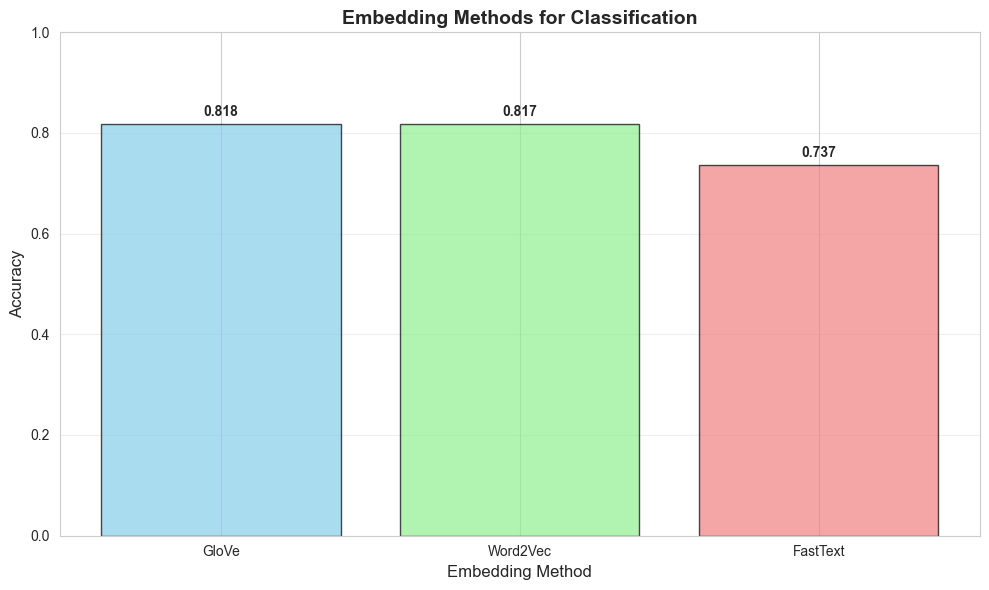


💡 Best embedding method for classification: GloVe (81.75% accuracy)
   Now let's explore how preprocessing affects classification!


In [21]:
# Compare all embedding methods for classification
if classification_results:
    print("\n" + "="*70)
    print("Embedding Methods Comparison for Classification")
    print("="*70)
    
    comparison_df = pd.DataFrame(classification_results).T
    comparison_df = comparison_df.sort_values('accuracy', ascending=False)
    comparison_df['Accuracy %'] = (comparison_df['accuracy'] * 100).round(2)
    
    print("\n" + comparison_df[['Accuracy %', 'precision', 'recall', 'f1']].to_string())
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    methods = comparison_df.index
    accuracies = comparison_df['accuracy'].values
    
    bars = ax.bar(methods, accuracies, color=['skyblue', 'lightgreen', 'lightcoral'], alpha=0.7, edgecolor='black')
    ax.set_title('Embedding Methods for Classification', fontsize=14, fontweight='bold')
    ax.set_xlabel('Embedding Method', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    best_method = comparison_df.index[0]
    best_accuracy = comparison_df.iloc[0]['accuracy']
    print(f"\n💡 Best embedding method for classification: {best_method} ({best_accuracy*100:.2f}% accuracy)")
    print("   Now let's explore how preprocessing affects classification!")
else:
    print("⚠️ No classification results available")


In [22]:
# Preprocessing functions
def preprocess_baseline(text):
    """No preprocessing - raw text"""
    return text

def preprocess_lowercase(text):
    """Only lowercase"""
    return text.lower()

def preprocess_remove_stopwords(text):
    """Lowercase + remove stopwords"""
    if not SPACY_AVAILABLE:
        return text.lower()
    doc = nlp(text.lower())
    tokens = [token.text for token in doc if not token.is_stop and not token.is_punct]
    return ' '.join(tokens)

def preprocess_lemmatize(text):
    """Lowercase + lemmatization"""
    if not SPACY_AVAILABLE:
        return text.lower()
    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc if not token.is_punct]
    return ' '.join(tokens)

def preprocess_handle_negation(text):
    """Lowercase + handle negation (simple approach: add NOT_ prefix)"""
    if not SPACY_AVAILABLE:
        return text.lower()
    doc = nlp(text.lower())
    tokens = []
    negate = False
    
    for token in doc:
        if token.dep_ == "neg":
            negate = True
        elif token.pos_ in ["NOUN", "ADJ", "ADV", "VERB"]:
            if negate:
                tokens.append(f"NOT_{token.text}")
                negate = False
            else:
                tokens.append(token.text)
        else:
            if negate and token.text not in ["not", "n't", "no"]:
                negate = False
            tokens.append(token.text)
    
    return ' '.join(tokens)

# Test preprocessing functions
test_text = "This movie is not good at all. I did not like it."
print("Original:", test_text)
print("Lowercase:", preprocess_lowercase(test_text))
print("Remove stopwords:", preprocess_remove_stopwords(test_text))
print("Lemmatize:", preprocess_lemmatize(test_text))
print("Handle negation:", preprocess_handle_negation(test_text))


Original: This movie is not good at all. I did not like it.
Lowercase: this movie is not good at all. i did not like it.
Remove stopwords: movie good like
Lemmatize: this movie be not good at all I do not like it
Handle negation: this movie is NOT_good at all . i did NOT_like it .


In [23]:
# Create embeddings and train classifiers for each preprocessing approach
if SPACY_AVAILABLE:
    preprocessing_methods = {
        'Baseline (no preprocessing)': preprocess_baseline,
        'Lowercase': preprocess_lowercase,
        'Remove stopwords': preprocess_remove_stopwords,
        'Lemmatization': preprocess_lemmatize,
        'Negation handling': preprocess_handle_negation
    }
    
    preprocessing_results = {}
    
    for method_name, preprocess_func in preprocessing_methods.items():
        print(f"\n{'='*70}")
        print(f"Testing: {method_name}")
        print('='*70)
        
        # Preprocess
        X_train_processed = [preprocess_func(text) for text in X_train]
        X_test_processed = [preprocess_func(text) for text in X_test]
        
        # Create embeddings (using spaCy for speed)
        print("Creating embeddings...")
        X_train_emb = np.array([nlp(text).vector for text in X_train_processed])
        X_test_emb = np.array([nlp(text).vector for text in X_test_processed])
        
        # Train classifier
        print("Training classifier...")
        classifier = LogisticRegression(max_iter=1000, random_state=42)
        classifier.fit(X_train_emb, y_train)
        
        # Evaluate
        y_pred = classifier.predict(X_test_emb)
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        preprocessing_results[method_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1
        }
        
        print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    # Create comparison DataFrame
    preprocessing_df = pd.DataFrame(preprocessing_results).T
    preprocessing_df = preprocessing_df.sort_values('accuracy', ascending=False)
    
    print("\n" + "="*70)
    print("Preprocessing Impact Comparison:")
    print("="*70)
    print(preprocessing_df.round(4))
    
else:
    print("⚠️ spaCy not available - skipping preprocessing experiments")
    preprocessing_df = None



Testing: Baseline (no preprocessing)
Creating embeddings...
Training classifier...
Accuracy: 0.6740 (67.40%)

Testing: Lowercase
Creating embeddings...
Training classifier...
Accuracy: 0.6765 (67.65%)

Testing: Remove stopwords
Creating embeddings...
Training classifier...
Accuracy: 0.6125 (61.25%)

Testing: Lemmatization
Creating embeddings...


KeyboardInterrupt: 

In [ ]:
# Visualization: Preprocessing impact
if preprocessing_df is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    methods = preprocessing_df.index
    accuracies = preprocessing_df['accuracy'].values
    
    bars = ax.bar(range(len(methods)), accuracies, color='skyblue', alpha=0.7, edgecolor='black')
    ax.set_title('Preprocessing Impact on Embeddings', fontsize=14, fontweight='bold')
    ax.set_xlabel('Preprocessing Method', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(methods, rotation=45, ha='right')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, (bar, acc) in enumerate(zip(bars, accuracies)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Key Insight: Preprocessing affects embeddings differently than TF-IDF!")
    print("   Sometimes less preprocessing is better - embeddings learn from context!")
    print("   Notice how negation handling might help - 'not good' ≠ 'good'")
else:
    print("⚠️ No preprocessing results available")


In [ ]:
# EDIT THIS: Try your own combination
preprocessing = {
    'lowercase': True,
    'remove_stopwords': False,
    'lemmatize': True,
    'handle_negation': True
}

print("Custom Preprocessing Configuration:")
print("="*70)
for key, value in preprocessing.items():
    print(f"  {key}: {value}")

# Apply custom preprocessing
def apply_custom_preprocessing(text, config):
    """Apply custom preprocessing based on config"""
    if config['lowercase']:
        text = text.lower()
    
    if not SPACY_AVAILABLE:
        return text
    
    doc = nlp(text)
    
    if config['handle_negation']:
        tokens = []
        negate = False
        for token in doc:
            if token.dep_ == "neg":
                negate = True
            elif token.pos_ in ["NOUN", "ADJ", "ADV", "VERB"]:
                if negate:
                    tokens.append(f"NOT_{token.text}")
                    negate = False
                else:
                    tokens.append(token.lemma_ if config['lemmatize'] else token.text)
            else:
                if negate and token.text not in ["not", "n't", "no"]:
                    negate = False
                if not config['remove_stopwords'] or not token.is_stop:
                    tokens.append(token.lemma_ if config['lemmatize'] else token.text)
        return ' '.join(tokens)
    else:
        tokens = []
        for token in doc:
            if token.is_punct:
                continue
            if config['remove_stopwords'] and token.is_stop:
                continue
            tokens.append(token.lemma_ if config['lemmatize'] else token.text)
        return ' '.join(tokens)

# Test custom preprocessing
X_train_custom = [apply_custom_preprocessing(text, preprocessing) for text in X_train]
X_test_custom = [apply_custom_preprocessing(text, preprocessing) for text in X_test]

# Create embeddings and evaluate
if SPACY_AVAILABLE:
    X_train_custom_emb = np.array([nlp(text).vector for text in X_train_custom])
    X_test_custom_emb = np.array([nlp(text).vector for text in X_test_custom])
    
    classifier_custom = LogisticRegression(max_iter=1000, random_state=42)
    classifier_custom.fit(X_train_custom_emb, y_train)
    
    y_pred_custom = classifier_custom.predict(X_test_custom_emb)
    accuracy_custom = accuracy_score(y_test, y_pred_custom)
    
    print(f"\nCustom Preprocessing Results:")
    print(f"Accuracy: {accuracy_custom:.4f} ({accuracy_custom*100:.2f}%)")
    
    if preprocessing_df is not None:
        best_baseline = preprocessing_df['accuracy'].max()
        print(f"Best baseline: {best_baseline:.4f} ({best_baseline*100:.2f}%)")
        print(f"Difference: {accuracy_custom - best_baseline:+.4f} ({((accuracy_custom - best_baseline) * 100):+.2f}%)")
else:
    print("⚠️ spaCy not available - skipping custom preprocessing")


---

## Section 4: POS Filtering

**POS Tagging: Filter Sentiment-Bearing Words - Do Adjectives/Adverbs Matter?**

**Question**: Do sentiment-bearing words (adjectives/adverbs) alone work better than full text?

**What is POS Tagging?**
- **POS** = Part-of-Speech (noun, verb, adjective, adverb, etc.)
- **Why it matters for sentiment**: Adjectives and adverbs often carry sentiment
  - Examples: "absolutely terrible" (ADV + ADJ), "very good" (ADV + ADJ)
- **The hypothesis**: Maybe filtering to only sentiment-bearing words improves accuracy?

**Reference**: 
- POS tagging is a fundamental NLP task
- spaCy automatically provides POS tags for each token
- Common tags: NOUN, VERB, ADJ (adjective), ADV (adverb), DET (determiner), etc.

**Key Insight**: 
- Sometimes less is more - filtering to important words can reduce noise
- But context matters - "not good" needs both "not" and "good"!
- We'll test if ADJ+ADV alone works better than full text


In [ ]:
# Apply POS tagging
if SPACY_AVAILABLE:
    print("Applying POS Tagging...")
    print("="*70)
    
    # Show POS distribution for a sample
    sample_texts = X_train[:10]
    pos_counts = {}
    
    for text in sample_texts:
        doc = nlp(text)
        for token in doc:
            if not token.is_punct:
                pos = token.pos_
                pos_counts[pos] = pos_counts.get(pos, 0) + 1
    
    print("POS Distribution (sample):")
    for pos, count in sorted(pos_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
        print(f"  {pos}: {count}")
    
    # Visualize POS distribution
    if pos_counts:
        fig, ax = plt.subplots(figsize=(10, 6))
        pos_items = sorted(pos_counts.items(), key=lambda x: x[1], reverse=True)[:10]
        pos_labels = [item[0] for item in pos_items]
        pos_values = [item[1] for item in pos_items]
        
        bars = ax.bar(pos_labels, pos_values, color='lightcoral', alpha=0.7, edgecolor='black')
        ax.set_title('POS Tag Distribution (Sample)', fontsize=14, fontweight='bold')
        ax.set_xlabel('POS Tag', fontsize=12)
        ax.set_ylabel('Count', fontsize=12)
        ax.grid(axis='y', alpha=0.3)
        
        # Highlight ADJ and ADV
        for i, (label, bar) in enumerate(zip(pos_labels, bars)):
            if label in ['ADJ', 'ADV']:
                bar.set_color('green')
                bar.set_alpha(0.8)
        
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
        print("\n💡 Green bars = ADJ (adjectives) and ADV (adverbs) - sentiment-bearing words!")
else:
    print("⚠️ spaCy not available - skipping POS tagging")


In [ ]:
# Filter to ADJ + ADV only
if SPACY_AVAILABLE:
    def filter_to_sentiment_words(text):
        """Keep only adjectives and adverbs"""
        doc = nlp(text.lower())
        tokens = [token.text for token in doc 
                 if token.pos_ in ['ADJ', 'ADV'] and not token.is_punct]
        return ' '.join(tokens)
    
    # Show example
    example_text = "This movie is absolutely terrible and boring."
    print("Example:")
    print(f"  Original: {example_text}")
    print(f"  ADJ+ADV only: {filter_to_sentiment_words(example_text)}")
    
    # Create filtered embeddings
    print("\nCreating embeddings with ADJ+ADV filtering...")
    X_train_pos_filtered = [filter_to_sentiment_words(text) for text in X_train]
    X_test_pos_filtered = [filter_to_sentiment_words(text) for text in X_test]
    
    X_train_pos_emb = np.array([nlp(text).vector if text.strip() else np.zeros(96) 
                                for text in X_train_pos_filtered])
    X_test_pos_emb = np.array([nlp(text).vector if text.strip() else np.zeros(96) 
                               for text in X_test_pos_filtered])
    
    # Train classifier
    classifier_pos = LogisticRegression(max_iter=1000, random_state=42)
    classifier_pos.fit(X_train_pos_emb, y_train)
    
    # Evaluate
    y_pred_pos = classifier_pos.predict(X_test_pos_emb)
    accuracy_pos = accuracy_score(y_test, y_pred_pos)
    precision_pos = precision_score(y_test, y_pred_pos)
    recall_pos = recall_score(y_test, y_pred_pos)
    f1_pos = f1_score(y_test, y_pred_pos)
    
    print(f"\nPOS Filtering Results (ADJ+ADV only):")
    print("="*70)
    print(f"Accuracy:  {accuracy_pos:.4f} ({accuracy_pos*100:.2f}%)")
    print(f"Precision: {precision_pos:.4f}")
    print(f"Recall:    {recall_pos:.4f}")
    print(f"F1-Score:  {f1_pos:.4f}")
    
    # Compare with full text (baseline from preprocessing experiments)
    if preprocessing_df is not None and 'Baseline (no preprocessing)' in preprocessing_df.index:
        baseline_acc = preprocessing_df.loc['Baseline (no preprocessing)', 'accuracy']
        print(f"\nComparison with Full Text:")
        print(f"  Full text accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
        print(f"  ADJ+ADV only accuracy: {accuracy_pos:.4f} ({accuracy_pos*100:.2f}%)")
        print(f"  Difference: {accuracy_pos - baseline_acc:+.4f} ({((accuracy_pos - baseline_acc) * 100):+.2f}%)")
    
    print("\n💡 Think: Do sentiment words alone work better? Why or why not?")
    print("   Sometimes context matters - 'not good' needs both 'not' and 'good'!")
else:
    print("⚠️ spaCy not available - skipping POS filtering")


---

## Section 5: NER Handling

**Named Entity Recognition: When Do Entities Matter?**

**Question**: When does NER help vs hurt for sentiment analysis?

**What is NER?**
- **NER** = Named Entity Recognition
- Identifies named entities: PERSON, ORGANIZATION, LOCATION, PRODUCT, etc.
- Example: "I love Apple products" → "Apple" is an ORGANIZATION entity

**Why It Matters for Sentiment**:
- Sometimes entities ARE the sentiment: "I love Apple" (entity is the object of sentiment)
- Sometimes entities distract: "Apple products are expensive" (entity is neutral, sentiment is about products)
- Sometimes entities provide context: "Tom Hanks was amazing" (actor name provides context)

**Reference**:
- NER is another fundamental NLP task
- spaCy automatically identifies entities in text
- Common entity types: PERSON, ORG, GPE (location), PRODUCT, etc.

**The Experiment**:
- We'll test removing entities vs keeping them
- Does removing entities help (by focusing on sentiment words)?
- Or does it hurt (by losing important context)?


In [ ]:
# Apply NER
if SPACY_AVAILABLE:
    print("Applying Named Entity Recognition (NER)...")
    print("="*70)
    
    # Show entity examples
    example_texts = [
        "I love Apple products but hate the price.",
        "This movie starring Tom Hanks is amazing.",
        "The film was shot in New York and Paris."
    ]
    
    print("Entity Examples:")
    for text in example_texts:
        doc = nlp(text)
        entities = [(ent.text, ent.label_) for ent in doc.ents]
        print(f"\n  Text: {text}")
        print(f"  Entities: {entities}")
    
    # Visualize entities in a sample
    sample_text = "I love Apple products but hate the price."
    doc = nlp(sample_text)
    
    print(f"\nVisualization:")
    print(f"  Original: {sample_text}")
    print(f"  Entities found:")
    for ent in doc.ents:
        print(f"    '{ent.text}' → {ent.label_}")
else:
    print("⚠️ spaCy not available - skipping NER")


In [ ]:
# Test: Remove entities
if SPACY_AVAILABLE:
    def remove_entities(text):
        """Remove named entities"""
        doc = nlp(text)
        tokens = []
        for token in doc:
            # Check if token is part of an entity
            is_entity = any(token.idx >= ent.start_char and token.idx < ent.end_char 
                           for ent in doc.ents)
            if not is_entity and not token.is_punct:
                tokens.append(token.text)
        return ' '.join(tokens)
    
    def replace_entities(text):
        """Replace entities with [ENTITY] tag"""
        doc = nlp(text)
        tokens = []
        for token in doc:
            # Check if token is part of an entity
            entity_label = None
            for ent in doc.ents:
                if token.idx >= ent.start_char and token.idx < ent.end_char:
                    entity_label = ent.label_
                    break
            
            if entity_label:
                # Only add [ENTITY] once per entity
                if token.idx == doc.ents[0].start_char if doc.ents else False:
                    tokens.append('[ENTITY]')
            elif not token.is_punct:
                tokens.append(token.text)
        return ' '.join(tokens)
    
    # Show examples
    example_text = "I love Apple products but hate the price."
    print("Example:")
    print(f"  Original: {example_text}")
    print(f"  Remove entities: {remove_entities(example_text)}")
    print(f"  Replace with [ENTITY]: {replace_entities(example_text)}")
    
    # Create embeddings and evaluate
    print("\nTesting entity removal...")
    X_train_no_entities = [remove_entities(text) for text in X_train]
    X_test_no_entities = [remove_entities(text) for text in X_test]
    
    X_train_no_ent_emb = np.array([nlp(text).vector for text in X_train_no_entities])
    X_test_no_ent_emb = np.array([nlp(text).vector for text in X_test_no_entities])
    
    classifier_no_ent = LogisticRegression(max_iter=1000, random_state=42)
    classifier_no_ent.fit(X_train_no_ent_emb, y_train)
    
    y_pred_no_ent = classifier_no_ent.predict(X_test_no_ent_emb)
    accuracy_no_ent = accuracy_score(y_test, y_pred_no_ent)
    
    print(f"\nNER Removal Results:")
    print(f"Accuracy: {accuracy_no_ent:.4f} ({accuracy_no_ent*100:.2f}%)")
    
    # Compare with baseline
    if preprocessing_df is not None and 'Baseline (no preprocessing)' in preprocessing_df.index:
        baseline_acc = preprocessing_df.loc['Baseline (no preprocessing)', 'accuracy']
        print(f"\nComparison:")
        print(f"  Baseline: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
        print(f"  Remove entities: {accuracy_no_ent:.4f} ({accuracy_no_ent*100:.2f}%)")
        print(f"  Difference: {accuracy_no_ent - baseline_acc:+.4f}")
    
    print("\n💡 Think: When does removing entities help vs hurt?")
    print("   Sometimes entities ARE the sentiment: 'I love Apple'")
    print("   Sometimes they distract: 'Apple products are expensive'")
else:
    print("⚠️ spaCy not available - skipping NER experiments")


---

## Section 6: Sentence Embeddings

**Sentence-BERT: Better Than Word Averaging?**

**Key Concept**: Sentence-BERT uses contrastive learning - similar sentences are pushed together, dissimilar sentences are pushed apart.

**Connection**: This uses the contrastive learning objective from the slides!

**What We've Been Doing So Far**:
- **Word averaging**: Average all word vectors in a sentence
  - Simple and fast
  - But loses word order ("not good" = "good not")
  - Treats all words equally

**What Sentence-BERT Does**:
- **Trained specifically for sentences**: Not just averaging words
- **Contrastive learning**: Similar sentences pushed together, dissimilar pushed apart
- **Captures context**: Understands word order and sentence structure
- **Better quality**: Usually outperforms word averaging

**Reference**:
- Sentence-BERT paper: Reimers & Gurevych, 2019 - "Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks"
- Model: `all-MiniLM-L6-v2` - optimized for speed and quality
- Training: Uses contrastive learning on sentence pairs

**Key Insight**: 
- Word averaging is simple but limited
- Sentence-BERT captures sentence-level meaning better
- This is what we learned about in the slides - contrastive learning!


In [ ]:
# Load Sentence-BERT and Understand Contrastive Learning
if SENTENCE_TRANSFORMERS_AVAILABLE:
    print("="*70)
    print("Loading Sentence-BERT Model")
    print("="*70)
    print("\nThis model was trained with CONTRASTIVE LEARNING:")
    print("  • Similar sentences → pushed together in embedding space")
    print("  • Dissimilar sentences → pushed apart in embedding space")
    print("\n💡 We're using a pre-trained model - explaining HOW it was trained (conceptually), not training it!")
    print("   This may take a minute on first run (downloading model)...\n")
    
    try:
        sentence_model = SentenceTransformer('all-MiniLM-L6-v2')
        print("✓ Sentence-BERT model loaded successfully!")
        print(f"  Model: all-MiniLM-L6-v2 (optimized for speed and quality)")
        print(f"  Embedding dimension: 384")
        
        # Demonstrate contrastive learning concept with examples
        print("\n" + "="*70)
        print("Demonstrating Contrastive Learning Concept")
        print("="*70)
        print("\n💡 This model was trained so that:")
        print("   • Similar sentences are CLOSE together")
        print("   • Dissimilar sentences are FAR apart")
        print("\nLet's see this in action:\n")
        
        similar_sentences = [
            "I love this movie!",
            "This film is great!",
            "I really enjoyed watching this."
        ]
        
        dissimilar_sentences = [
            "I love this movie!",
            "I hate this movie!",
            "This film is terrible."
        ]
        
        print("Similar sentences (should be CLOSE - high similarity):")
        print("-" * 70)
        for i, sent1 in enumerate(similar_sentences):
            for sent2 in similar_sentences[i+1:]:
                emb1 = sentence_model.encode(sent1)
                emb2 = sentence_model.encode(sent2)
                similarity = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
                print(f"  '{sent1}' ↔ '{sent2}': {similarity:.4f} ✓ (close!)")
        
        print("\nDissimilar sentences (should be FAR - low similarity):")
        print("-" * 70)
        for sent in dissimilar_sentences[1:]:
            emb1 = sentence_model.encode(dissimilar_sentences[0])
            emb2 = sentence_model.encode(sent)
            similarity = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
            print(f"  '{dissimilar_sentences[0]}' ↔ '{sent}': {similarity:.4f} ✓ (far apart!)")
        
        print("\n" + "="*70)
        print("💡 Key Insight: Contrastive Learning in Action!")
        print("   • Similar sentences → high similarity (close in embedding space)")
        print("   • Dissimilar sentences → low similarity (far in embedding space)")
        print("   • This is HOW Sentence-BERT was trained (conceptually)!")
        print("   • Now let's use it for classification and compare with word averaging!")
        
    except Exception as e:
        print(f"⚠️ Error loading Sentence-BERT: {e}")
        sentence_model = None
else:
    print("⚠️ sentence-transformers not available - skipping Sentence-BERT")
    print("   Install with: pip install sentence-transformers")
    sentence_model = None


In [ ]:
# Create sentence embeddings and compare with word averaging
if sentence_model is not None:
    print("\nCreating Sentence-BERT embeddings...")
    print("This may take a few minutes...")
    
    # Sentence-BERT embeddings
    X_train_sbert = sentence_model.encode(X_train, show_progress_bar=False)
    X_test_sbert = sentence_model.encode(X_test, show_progress_bar=False)
    
    print(f"✓ Sentence-BERT embeddings created!")
    print(f"  Shape: {X_train_sbert.shape}")
    
    # Train Sentence-BERT classifier
    print("\nTraining classifier with Sentence-BERT embeddings...")
    classifier_sbert = LogisticRegression(max_iter=1000, random_state=42)
    classifier_sbert.fit(X_train_sbert, y_train)
    
    # Evaluate Sentence-BERT
    y_pred_sbert = classifier_sbert.predict(X_test_sbert)
    accuracy_sbert = accuracy_score(y_test, y_pred_sbert)
    precision_sbert = precision_score(y_test, y_pred_sbert)
    recall_sbert = recall_score(y_test, y_pred_sbert)
    f1_sbert = f1_score(y_test, y_pred_sbert)
    
    print(f"\n✓ Sentence-BERT classifier trained!")
    
    # Compare with word averaging baseline (from Section 1)
    if accuracy_word_avg is not None:
        print("\n" + "="*70)
        print("Comparison: Sentence-BERT vs Word Averaging")
        print("="*70)
        
        print(f"\nWord Averaging (Baseline):")
        print(f"  Accuracy: {accuracy_word_avg:.4f} ({accuracy_word_avg*100:.2f}%)")
        
        print(f"\nSentence-BERT:")
        print(f"  Accuracy: {accuracy_sbert:.4f} ({accuracy_sbert*100:.2f}%)")
        print(f"  Precision: {precision_sbert:.4f}")
        print(f"  Recall: {recall_sbert:.4f}")
        print(f"  F1-Score: {f1_sbert:.4f}")
        
        improvement = accuracy_sbert - accuracy_word_avg
        print(f"\n{'='*70}")
        print(f"Improvement: {improvement:+.4f} ({improvement*100:+.2f} percentage points)")
        print(f"{'='*70}")
        
        # Visualization
        fig, ax = plt.subplots(figsize=(10, 6))
        methods = ['Word Averaging\n(Baseline)', 'Sentence-BERT\n(Contrastive Learning)']
        accuracies = [accuracy_word_avg, accuracy_sbert]
        colors = ['orange', 'green']
        
        bars = ax.bar(methods, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
        ax.set_title('Sentence Embeddings Comparison for Classification', fontsize=14, fontweight='bold')
        ax.set_ylabel('Accuracy', fontsize=12)
        ax.set_ylim([0, 1])
        ax.grid(axis='y', alpha=0.3)
        
        for bar, acc in zip(bars, accuracies):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{acc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
        
        plt.tight_layout()
        plt.show()
        
        print("\n💡 Key Insights:")
        print("   • Sentence-BERT (trained with contrastive learning) outperforms word averaging!")
        print("   • Captures sentence-level meaning, word order, and context better")
        print("   • This is why sentence embeddings are better than averaging word embeddings!")
    else:
        print(f"\nSentence-BERT Results:")
        print(f"  Accuracy: {accuracy_sbert:.4f} ({accuracy_sbert*100:.2f}%)")
        print(f"  Precision: {precision_sbert:.4f}")
        print(f"  Recall: {recall_sbert:.4f}")
        print(f"  F1-Score: {f1_sbert:.4f}")
        print("\n💡 Sentence-BERT captures sentence-level meaning better than word averaging!")
        print("   (No baseline comparison available - word averaging baseline not computed)")
else:
    print("⚠️ Sentence-BERT not available - skipping sentence embeddings")
    print("   Install with: pip install sentence-transformers")


---

## Section 7: Final Summary

**What We've Learned:**

1. ✅ **Word Averaging (Baseline)**: Simple approach from Part 1 - averaging word embeddings to create sentence embeddings
2. ✅ **How Sentence/Document Embeddings Are Learned**: Three training objectives (conceptually explained!)
   - **Next-token prediction** (GPT style) - predicting what's next → adjusts vectors to understand context
   - **Masked Language Modeling** (BERT style) - predicting what's missing → adjusts vectors to understand bidirectional context
   - **Contrastive learning** (Sentence-BERT style) - predicting what's similar → adjusts vectors to push similar together, dissimilar apart
3. ✅ **Key Concept**: **LEARN = Adjust the Vectors**
   - Learning means adjusting vector representations (the numbers in embeddings)
   - Based on training objectives (what we want to predict)
   - To better capture meaning (semantic understanding)
4. ✅ **Sentence-Level Embeddings**: BERT and Sentence-BERT - better than word averaging!
5. ✅ **Classification with Sentence Embeddings**: Sentence-BERT outperforms word averaging!

**Key Takeaways**:
- **LEARN = Adjust the Vectors**: All three training methods adjust vector representations based on objectives
- **All require understanding context first**: To predict next word, masked word, or similarity, models must understand context
- **Sentence embeddings** capture sentence-level meaning, word order, and context better than averaging word embeddings
- **Next-token prediction** (GPT): Learns by predicting what comes next (left-to-right context)
- **Masked Language Modeling** (BERT): Learns by predicting masked words (bidirectional context - better!)
- **Contrastive learning** (Sentence-BERT): Learns by distinguishing similar/dissimilar sentences (best for sentence embeddings!)
- **Sentence-BERT** combines BERT's MLM understanding + contrastive learning → outperforms word averaging for classification

**Supervised Learning Summary** (preview - you'll learn this in depth later!):
- We used **Logistic Regression** (from Chapter 0) for classification - this is supervised learning
- We evaluated using **accuracy, precision, recall, F1-score** (will be covered in depth later)
- We compared **word averaging** vs **sentence embeddings** (Sentence-BERT) for classification
- **The goal**: See how sentence-level embeddings improve classification compared to word averaging!
- **Key takeaway**: Sentence embeddings (trained with contrastive learning) capture sentence-level meaning better than averaging word embeddings. This enables better classification! You'll learn supervised learning, feature engineering, and evaluation in depth later - for now, see how sentence embeddings transform text into dense vectors that enable classification!


In [ ]:
# Final Results Summary
print("="*70)
print("Final Results Summary")
print("="*70)

results_summary = {}

# Add word averaging baseline
if accuracy_word_avg is not None:
    results_summary['Word Averaging (Baseline)'] = {
        'accuracy': accuracy_word_avg,
        'method': 'Word-level embeddings averaged'
    }

# Add Sentence-BERT
if 'accuracy_sbert' in locals():
    results_summary['Sentence-BERT (Contrastive Learning)'] = {
        'accuracy': accuracy_sbert,
        'precision': precision_sbert,
        'recall': recall_sbert,
        'f1': f1_sbert,
        'method': 'Sentence-level embeddings (BERT + Contrastive Learning)'
    }

# Create summary DataFrame
if results_summary:
    summary_df = pd.DataFrame(results_summary).T
    
    print("\nComparison Results:")
    print("-" * 70)
    for method, row in summary_df.iterrows():
        print(f"\n{method}:")
        print(f"  Accuracy: {row['accuracy']:.4f} ({row['accuracy']*100:.2f}%)")
        if 'precision' in row:
            print(f"  Precision: {row['precision']:.4f}")
            print(f"  Recall: {row['recall']:.4f}")
            print(f"  F1-Score: {row['f1']:.4f}")
        print(f"  Method: {row['method']}")
    
    # Visualization
    if len(results_summary) > 1:
        fig, ax = plt.subplots(figsize=(10, 6))
        methods = list(results_summary.keys())
        accuracies = [results_summary[m]['accuracy'] for m in methods]
        colors = ['orange', 'green']
        
        bars = ax.bar(methods, accuracies, color=colors[:len(methods)], alpha=0.7, edgecolor='black', linewidth=2)
        ax.set_title('Sentence Embeddings: Word Averaging vs Sentence-BERT', fontsize=14, fontweight='bold')
        ax.set_ylabel('Accuracy', fontsize=12)
        ax.set_ylim([0, 1])
        ax.grid(axis='y', alpha=0.3)
        
        for bar, acc in zip(bars, accuracies):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{acc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
        
        plt.xticks(rotation=15, ha='right')
        plt.tight_layout()
        plt.show()
        
        if accuracy_word_avg is not None and 'accuracy_sbert' in locals():
            improvement = accuracy_sbert - accuracy_word_avg
            print(f"\n{'='*70}")
            print(f"💡 Sentence-BERT improves accuracy by {improvement:+.4f} ({improvement*100:+.2f} percentage points)!")
            print(f"{'='*70}")
    
    print("\n💡 Key Insight: Sentence-level embeddings (Sentence-BERT) outperform word averaging!")
    print("   • Trained with contrastive learning - captures sentence meaning better")
    print("   • Handles word order and context")
    print("   • Better for classification tasks!")
else:
    print("⚠️ No results available for summary")


In [ ]:
# Error analysis - show misclassified examples
if 'classifier_sbert' in locals() or 'classifier_pos' in locals():
    print("\nError Analysis - Misclassified Examples:")
    print("="*70)
    
    # Use best classifier available
    if 'classifier_sbert' in locals():
        y_pred_best = y_pred_sbert
        classifier_best = classifier_sbert
        method_name = "Sentence-BERT"
    elif 'classifier_pos' in locals():
        y_pred_best = y_pred_pos
        classifier_best = classifier_pos
        method_name = "POS Filtering"
    else:
        y_pred_best = None
    
    if y_pred_best is not None:
        # Find misclassified examples
        misclassified_indices = np.where(y_test != y_pred_best)[0]
        
        print(f"\nShowing 5 misclassified examples ({method_name}):")
        print(f"Total misclassified: {len(misclassified_indices)} out of {len(y_test)}")
        
        for i, idx in enumerate(misclassified_indices[:5]):
            true_label = "positive" if y_test[idx] == 1 else "negative"
            pred_label = "positive" if y_pred_best[idx] == 1 else "negative"
            
            print(f"\nExample {i+1}:")
            print(f"  Text: {X_test[idx][:150]}...")
            print(f"  True label: {true_label}")
            print(f"  Predicted: {pred_label}")
            
            # Try to identify why it failed
            if true_label == "positive" and pred_label == "negative":
                print(f"  💡 Why it failed: Positive review misclassified as negative")
                print(f"     Possible reasons: Sarcasm? Mixed sentiment? Context needed?")
            else:
                print(f"  💡 Why it failed: Negative review misclassified as positive")
                print(f"     Possible reasons: Subtle negativity? Missing context?")
        
        print("\n💡 Key Takeaways:")
        print("  • Some errors are inevitable - language is complex!")
        print("  • Sarcasm and mixed sentiment are challenging")
        print("  • Context matters - sometimes full sentence needed")
        print("  • Preprocessing choices affect results")
else:
    print("⚠️ No classifier available for error analysis")


---

## Final Summary

**What You Learned:**

1. ✅ **Word Averaging (Baseline)**: Simple approach - averaging word embeddings to create sentence embeddings (from Part 1)
2. ✅ **How Sentence/Document Embeddings Are Learned**: Three training objectives (conceptually explained!)
   - **Next-token prediction** (GPT style) - predicting what's next → adjusts vectors to understand context
   - **Masked Language Modeling** (BERT style) - predicting what's missing → adjusts vectors to understand bidirectional context
   - **Contrastive learning** (Sentence-BERT style) - predicting what's similar → adjusts vectors to push similar together, dissimilar apart
3. ✅ **Key Concept**: **LEARN = Adjust the Vectors**
   - Learning means adjusting vector representations (the numbers in embeddings)
   - Based on training objectives (what we want to predict)
   - To better capture meaning (semantic understanding)
4. ✅ **Sentence-Level Embeddings**: BERT and Sentence-BERT - better than word averaging!
5. ✅ **Classification with Sentence Embeddings**: Sentence-BERT outperforms word averaging for sentiment classification!

**Key Insights:**

- **LEARN = Adjust the Vectors**: All three training methods adjust vector representations based on objectives
- **All require understanding context first**: To predict next word, masked word, or similarity, models must understand context
- **Next-token prediction** (GPT): Learns by predicting what comes next (left-to-right context)
- **Masked Language Modeling** (BERT): Learns by predicting masked words (bidirectional context - better!)
- **Contrastive learning** (Sentence-BERT): Learns by distinguishing similar/dissimilar sentences (best for sentence embeddings!)
- **Sentence Embeddings**: Capture sentence-level meaning, word order, and context better than averaging word embeddings
- **Sentence-BERT**: Combines BERT's MLM understanding + contrastive learning → outperforms word averaging!

**Supervised Learning Summary** (preview - you'll learn this in depth later!):
- We used **Logistic Regression** (from Chapter 0) for classification - this is supervised learning
- We compared **word averaging** vs **sentence embeddings** (Sentence-BERT) for classification
- We used **evaluation metrics** (accuracy, precision, recall, F1) to compare methods
- **Key takeaway**: Sentence embeddings (trained with contrastive learning) capture sentence-level meaning better than averaging word embeddings. This enables better classification! You'll learn supervised learning, feature engineering, and evaluation metrics in depth later. For now, see how sentence embeddings transform text into dense vectors that enable classification tasks!

**The Complete Picture**:
- **Class 1 & 2**: Syntactic representations (TF-IDF) - word-based, no meaning (used for search)
- **Class 3 Part 1**: Word embeddings (Word2Vec, GloVe, FastText) - understand word meaning, semantic search
- **Class 3 Part 2**: Sentence embeddings (BERT, Sentence-BERT) - understand sentence meaning, better classification!

**References**:
- Sentence-BERT: Reimers & Gurevych, 2019 - "Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks"
- BERT: Devlin et al., 2018 - "BERT: Pre-training of Deep Bidirectional Transformers"
- Class 1 & 2: Preprocessing techniques, TF-IDF, vector representations
- Chapter 0: Logistic Regression for classification
- Theory Guide (Class 3.md): Complete explanations of all concepts (MLM, contrastive learning)

**Remember**: **LEARN = Adjust the Vectors**! Sentence/document embeddings learn by adjusting vector representations based on training objectives. All three methods (next-token prediction, masked language modeling, contrastive learning) require understanding context first, then adjust vectors to improve predictions. **Sentence embeddings** (BERT, Sentence-BERT) capture sentence-level meaning, word order, and context better than averaging word embeddings! Sentence-BERT combines BERT's bidirectional understanding (MLM) with contrastive learning - similar sentences pushed together, dissimilar sentences pushed apart. This enables better classification and understanding of text!
